# 01 - EDA and Coverage Risk Model Comparison
Dataset: `coverwise_synthetic_coverage_risk_dataset_500.csv` (resource pack, Dataset 2).

Goals: understand the features, check label balance, find leakage, derive the transparent rule-based score, and compare Logistic Regression / Decision Tree / Random Forest / Gradient Boosting.

In [1]:
import sys, json
sys.path.insert(0, '..')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from coverwise import config
df = pd.read_csv(config.SYNTHETIC_DATASET)
print(df.shape)
df.head()

(500, 21)


,policy_id,policy_type,sum_insured,annual_premium,premium_to_coverage_ratio,waiting_period_months,pre_existing_disease_waiting_period_months,copayment_percentage,room_rent_limit_present,icu_limit_present,...,exclusion_count,restoration_benefit_present,no_claim_bonus_present,child_coverage_present,maternity_coverage_present,claim_process_clarity_score,ambiguous_clause_count,risk_flags_count,coverage_clarity_score,risk_label
0,CW-0001,Senior Citizen,300000,14900,0.0497,3,12,0,1,0,...,21,1,1,1,0,38,2,3,95,Strong Coverage
1,CW-0002,Senior Citizen,2500000,55800,0.0223,48,24,20,1,0,...,13,1,1,0,0,83,0,4,68,Moderate Coverage
2,CW-0003,Senior Citizen,300000,14700,0.0490,36,0,30,0,0,...,22,0,1,1,1,64,3,6,28,High Risk
3,CW-0004,Group Health,500000,8500,0.0170,24,24,0,0,0,...,5,1,1,0,1,83,1,2,100,Strong Coverage
4,CW-0005,Senior Citizen,1000000,46500,0.0465,0,12,20,0,0,...,21,0,1,0,0,93,0,3,66,Moderate Coverage


In [2]:
df.isna().sum().sum(), df.dtypes.value_counts()

(np.int64(0),
 int64      17
 str         3
 float64     1
 Name: count, dtype: int64)

## Label balance
High Risk has only 33 rows -> use stratified splits, `class_weight='balanced'` and **macro-F1** instead of accuracy.

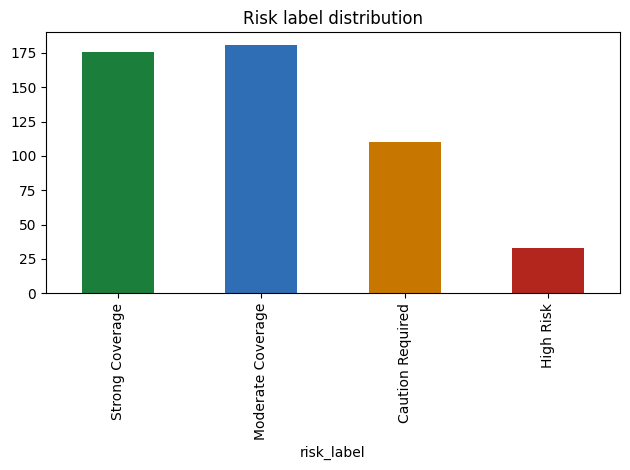

risk_label
Moderate Coverage    181
Strong Coverage      176
Caution Required     110
High Risk             33
Name: count, dtype: int64

In [3]:
ax = df.risk_label.value_counts().reindex(config.RISK_LABELS).plot.bar(color=['#1B7F3B','#2F6DB5','#C77700','#B3261E'])
ax.set_title('Risk label distribution'); plt.tight_layout(); plt.show()
df.risk_label.value_counts()

## Score bands per label
The bands overlap (Strong 78-100 vs Moderate 58-87), so the label is not a pure threshold on the score - a classifier is needed.

In [4]:
df.groupby('risk_label').coverage_clarity_score.agg(['min','max','mean']).reindex(config.RISK_LABELS)

,min,max,mean
risk_label,,,
Strong Coverage,78,100,89.590909
Moderate Coverage,58,87,69.314917
Caution Required,38,57,48.618182
High Risk,13,37,29.545455


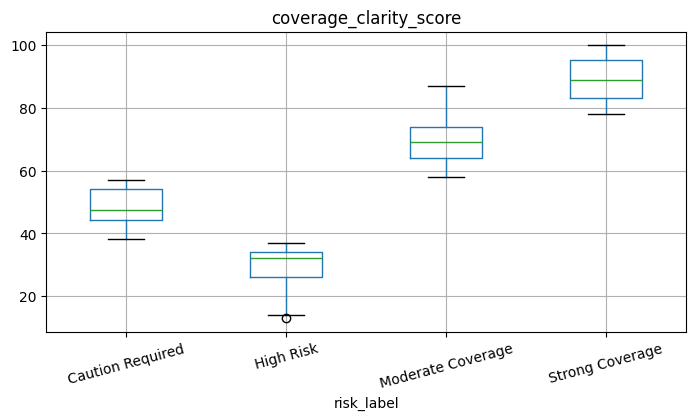

In [5]:
df.boxplot(column='coverage_clarity_score', by='risk_label', figsize=(8,4), rot=15); plt.suptitle(''); plt.show()

## Correlation with the clarity score
`coverage_clarity_score` is derived from the same information as the label, so it is **excluded from the model inputs** (leakage).

In [6]:
num = df.drop(columns=['policy_id','policy_type','risk_label'])
num.corr()['coverage_clarity_score'].drop('coverage_clarity_score').sort_values()

risk_flags_count                             -0.877322
copayment_percentage                         -0.535306
pre_existing_disease_waiting_period_months   -0.388507
ambiguous_clause_count                       -0.295463
room_rent_limit_present                      -0.204846
waiting_period_months                        -0.190456
exclusion_count                              -0.172442
disease_sub_limit_count                      -0.154429
icu_limit_present                            -0.115879
child_coverage_present                       -0.027968
sum_insured                                  -0.000726
premium_to_coverage_ratio                     0.015653
annual_premium                                0.025068
maternity_coverage_present                    0.064747
claim_process_clarity_score                   0.101758
no_claim_bonus_present                        0.306240
restoration_benefit_present                   0.444697
Name: coverage_clarity_score, dtype: float64

## Deriving the transparent rule-based score
A linear regression explains ~96% of the score. Rounded coefficients become the readable 'points' in `coverwise/scoring.py`.

In [7]:
from sklearn.linear_model import LinearRegression
X = df[config.MODEL_FEATURES]; y = df.coverage_clarity_score
lr = LinearRegression().fit(X, y)
print('R2 =', round(lr.score(X, y), 3), '| intercept =', round(lr.intercept_, 1))
pd.Series(lr.coef_, X.columns).round(3).sort_values()

R2 = 0.964 | intercept = 102.7


premium_to_coverage_ratio                    -26.167
risk_flags_count                              -6.944
ambiguous_clause_count                        -1.928
copayment_percentage                          -0.760
room_rent_limit_present                       -0.279
pre_existing_disease_waiting_period_months    -0.251
disease_sub_limit_count                       -0.093
icu_limit_present                             -0.047
claim_process_clarity_score                   -0.017
sum_insured                                   -0.000
annual_premium                                 0.000
waiting_period_months                          0.010
exclusion_count                                0.026
child_coverage_present                         0.445
maternity_coverage_present                     0.821
no_claim_bonus_present                         4.846
restoration_benefit_present                   10.051
dtype: float64

## What is `risk_flags_count`?
Counting 10 simple rules reproduces it (correlation ~0.95). The same rules are used at inference time (`coverwise/features.py`), so features from real PDFs match the training data.

In [8]:
flags = ((df.pre_existing_disease_waiting_period_months>=36).astype(int) + (df.copayment_percentage>=10) + df.room_rent_limit_present + df.icu_limit_present + (df.disease_sub_limit_count>=3) + (df.exclusion_count>=15) + (df.ambiguous_clause_count>=3) + (1-df.restoration_benefit_present) + (df.claim_process_clarity_score<60) + (df.waiting_period_months>=24))
print('corr =', round(np.corrcoef(flags, df.risk_flags_count)[0,1], 3), '| exact match =', round((flags==df.risk_flags_count).mean(), 3))

corr = 0.955 | exact match = 0.658


## Model comparison
`train_models()` runs 5-fold stratified CV on the training split, evaluates on a 20% held-out test set, compares with the rule baseline and saves the best model.

In [9]:
from coverwise.scoring import train_models
m = train_models()
pd.DataFrame(m['model_comparison']).T

,cv_macro_f1_mean,cv_macro_f1_std,test_accuracy,test_macro_f1
Logistic Regression,0.8294,0.0393,0.84,0.7748
Decision Tree,0.6598,0.0517,0.73,0.6571
Random Forest,0.6412,0.0846,0.81,0.6697
Gradient Boosting,0.7508,0.0721,0.79,0.7153


In [10]:
print('Best model:', m['best_model'])
print('Rule baseline:', m['rule_baseline'])
print('Score regressor:', m['score_regressor'])
pd.DataFrame(m['best_model_test_report']).T.round(2)

Best model: Logistic Regression
Rule baseline: {'test_accuracy': 0.85, 'test_macro_f1': 0.7851, 'score_mae': 3.21}
Score regressor: {'test_mae': 3.18, 'test_r2': 0.957}


,precision,recall,f1-score,support
Caution Required,0.81,0.77,0.79,22.00
High Risk,0.50,0.57,0.53,7.00
Moderate Coverage,0.86,0.89,0.88,36.00
Strong Coverage,0.91,0.89,0.90,35.00
accuracy,0.84,0.84,0.84,0.84
macro avg,0.77,0.78,0.77,100.00
weighted avg,0.84,0.84,0.84,100.00


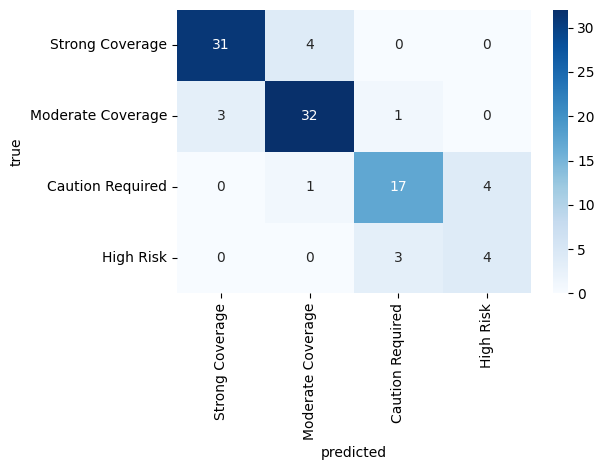

In [11]:
import seaborn as sns
cm = pd.DataFrame(m['confusion_matrix'], index=config.RISK_LABELS, columns=config.RISK_LABELS)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues'); plt.ylabel('true'); plt.xlabel('predicted'); plt.tight_layout(); plt.show()

## Findings
- Logistic Regression wins because the synthetic score is close to linear in the features.
- High Risk is the weakest class (few samples) - in the app every High Risk result says *Needs Advisor Review* and shows the reasons.
- The model is trained on **synthetic** data: the score describes how clear/restrictive the wording is, not insurer quality or claim settlement. This limitation is stated in every report.